In [1]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
import warnings
import importlib
from lightning import seed_everything

In [2]:
seed_everything(0, verbose=False)

# set the device to gpu if available, otherwise use cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device {}".format(device))
img_idx = 0  # TODO: change to the index of the image you want to visualize
coco_config_path = "./configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
cityscapes_config_path ="./configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
data_path = r"E:\Polito\First Year\Semester II\Fundamentals of AI\eomt\data\city_scapes\gtFine"  # TODO: change to the dataset directory

with open(coco_config_path, "r") as f:
    coco_config = yaml.safe_load(f)

with open(cityscapes_config_path, "r") as f:
    cityscapes_config = yaml.safe_load(f)


def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

Selected device cuda


In [3]:
# for performance on my PC
torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True


In [4]:
data_module_name, class_name = cityscapes_config["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = cityscapes_config["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=6,

    check_empty_targets=False,
    **data_module_kwargs
).setup(stage="validate")

In [5]:
print(data.num_classes)
print(data.img_size)

19
(1024, 1024)


In [6]:
val_loader = data.val_dataloader()

# Defining initial evaluation function
the function `evaluate_semantic_segmentation_eomt` computes the mean Intersection over Union (mIoU) for a semantic segmentation model. It iterates through the validation dataset, making predictions and comparing them to the ground truth labels to calculate the intersection and union for each class. Finally, it returns the mIoU and the IoU for each class.

In [7]:
IGNORE_INDEX = 255 # honestly i have no idea what is this

def infer_semantic(img, target,model=None):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [8]:
# import torch
# import torch
#
# def evaluate_semantic_segmentation_eomt(
#     model,
#     dataloader,
#     num_classes=19,
#     ignore_index=255,
#     device="cuda",
# ):
#     """
#     Semantic segmentation evaluation for EoMT models on Cityscapes.
#
#     IMPORTANT (explicit batch handling):
#     - Cityscapes semantic dataloader yields ([img], [target])
#     - img_list[0]      -> torch.Tensor
#     - target_list[0]   -> dict (e.g. {"semantic": Tensor, ...})
#     """
#
#     model.eval()
#
#     intersection = torch.zeros(num_classes)
#     union = torch.zeros(num_classes)
#
#     with torch.no_grad():
#         for batch in dataloader:
#             # Cityscapes semantic batch structure
#             img_list, target_list = batch
#
#             # Unwrap image
#             img = img_list[0].to(device)
#
#             # Unwrap target dict
#             target_item = target_list[0]
#             if isinstance(target_item, dict):
#                 target = (
#                     target_item.get("semantic")
#                     if "semantic" in target_item
#                     else target_item.get("label")
#                 )
#             else:
#                 target = target_item.to(device)
#
#             # Canonical EoMT semantic inference
#             pred_array, target_array = infer_semantic(
#                 img, target, model=model
#             )
#
#             pred = torch.from_numpy(pred_array)
#             gt = torch.from_numpy(target_array)
#
#             for cls in range(num_classes):
#                 if cls == ignore_index:
#                     continue
#
#                 pred_mask = pred == cls
#                 gt_mask = gt == cls
#
#                 intersection[cls] += (pred_mask & gt_mask).sum()
#                 union[cls] += (pred_mask | gt_mask).sum()
#
#     iou = intersection / (union + 1e-6)
#     miou = iou.mean().item()
#
#     return {
#         "mIoU": miou,
#         "IoU_per_class": iou.tolist(),
#     }

# ## Load model and evaluate
Load the model checkpoint and evaluate it on the validation set using the `evaluate_semantic_segmentation` function defined above.

In [9]:
import importlib
import warnings



def build_model_from_config(config, data, device, ckpt_path: str | None = None):
    """
    Build the Lightning model exactly following the training config logic.

    IMPORTANT ASSUMPTION (explicit):
    - The evaluation architecture always matches the Cityscapes *semantic* config.
    - COCO-trained checkpoints are loaded *partially* and only compatible weights
      (e.g. backbone + transformer blocks) are reused.
    - Query embeddings, class heads, positional embeddings and criterion weights
      are intentionally skipped when shapes do not match.
    """

    # Silence Lightning warning about nested modules
    warnings.filterwarnings(
        "ignore",
        message=r".*Attribute 'network' is an instance of `nn\\.Module` and is already saved during checkpointing.*",
    )

    # ------------------------------------------------------------------
    # Encoder
    # ------------------------------------------------------------------
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    enc_mod, enc_cls = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(enc_mod), enc_cls)
    encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

    # ------------------------------------------------------------------
    # Network
    # ------------------------------------------------------------------
    network_cfg = config["model"]["init_args"]["network"]
    net_mod, net_cls = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(net_mod), net_cls)

    network_kwargs = {
        k: v for k, v in network_cfg["init_args"].items() if k != "encoder"
    }

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=data.num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # ------------------------------------------------------------------
    # Lightning module
    # ------------------------------------------------------------------
    lit_mod, lit_cls_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_mod), lit_cls_name)

    model_kwargs = {
        k: v for k, v in config["model"]["init_args"].items() if k != "network"
    }

    if "stuff_classes" in config.get("data", {}).get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    model = (
        lit_cls(
            img_size=data.img_size,
            num_classes=data.num_classes,
            network=network,
            **model_kwargs,
        )
        .eval()
        .to(device)
    )

    # ------------------------------------------------------------------
    # Load local checkpoint (robust partial loading)
    # ------------------------------------------------------------------
    if ckpt_path is not None:
        raw_state_dict = torch.load(ckpt_path, map_location=device, weights_only=True)

        model_state = model.state_dict()
        filtered_state = {}
        skipped = []

        for k, v in raw_state_dict.items():
            if k not in model_state:
                skipped.append(k)
                continue
            if model_state[k].shape != v.shape:
                skipped.append(k)
                continue
            filtered_state[k] = v

        missing, unexpected = model.load_state_dict(filtered_state, strict=False)

        print("[Checkpoint loading]")
        print(f"  Loaded keys: {len(filtered_state)}")
        print(f"  Skipped keys (incompatible): {len(skipped)}")
        print(f"  Missing keys after load: {len(missing)}")

    else:
        warnings.warn("No checkpoint path provided; model is randomly initialized.")

    return model


In [10]:
model_ctiy_scapes = build_model_from_config(cityscapes_config, data, device, ckpt_path=r"E:\Polito\First Year\Semester II\Fundamentals of AI\Project\eomt\model_checkpoints\eomt_cityscapes.bin")

C:\Users\omarh\anaconda3\envs\eomt\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


[Checkpoint loading]
  Loaded keys: 198
  Skipped keys (incompatible): 0
  Missing keys after load: 0


In [11]:

model_coco = build_model_from_config(cityscapes_config, data, device, ckpt_path=r"E:\Polito\First Year\Semester II\Fundamentals of AI\Project\eomt\model_checkpoints\eomt_coco.bin")

C:\Users\omarh\anaconda3\envs\eomt\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


[Checkpoint loading]
  Loaded keys: 193
  Skipped keys (incompatible): 5
  Missing keys after load: 5


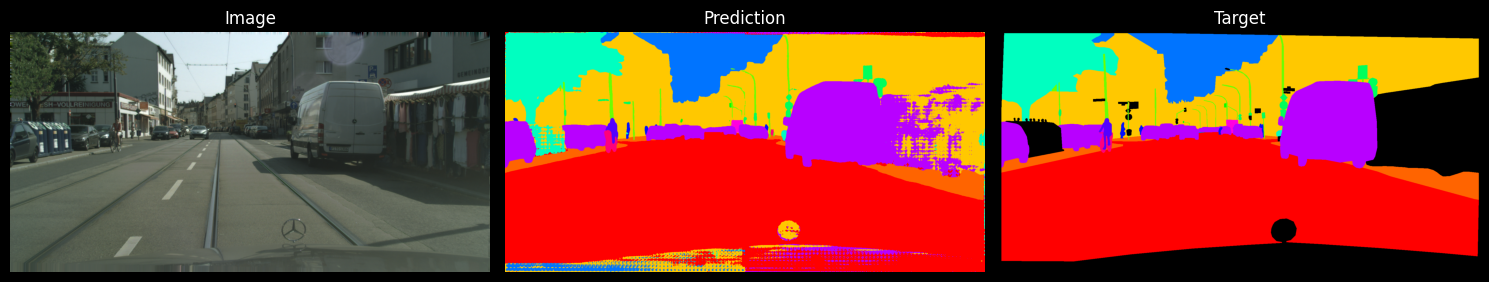

In [12]:

img, target = data.val_dataloader().dataset[4]
pred_array, target_array = infer_semantic(img, target,model=model_ctiy_scapes)
plot_semantic_results(img, pred_array, target_array)

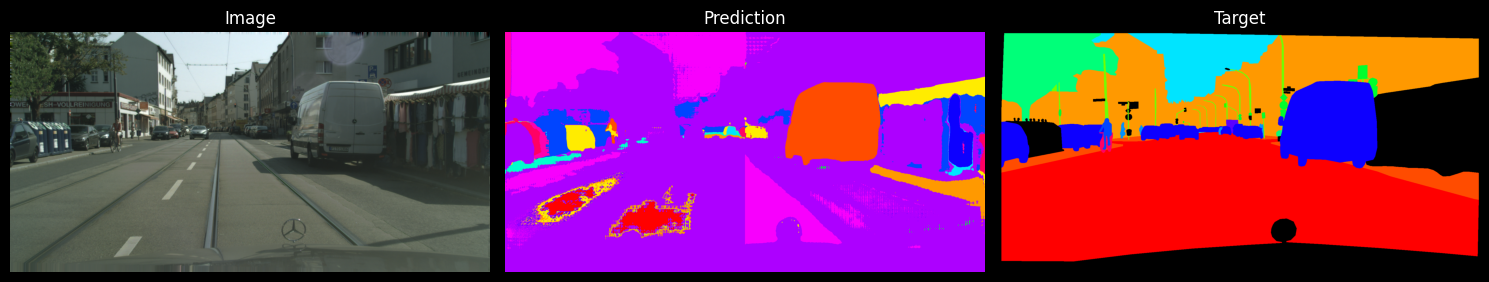

In [13]:
img, target = data.val_dataloader().dataset[4]
pred_array, target_array = infer_semantic(img, target,model=model_coco)
plot_semantic_results(img, pred_array, target_array)

In [14]:
model_ctiy_scapes.plot_semantic = lambda *args, **kwargs: None
model_coco.plot_semantic = lambda *args, **kwargs: None

In [15]:
from lightning import Trainer

trainer = Trainer(
    accelerator="gpu",
    devices=1,
    logger=False,
  #  precision="16-mixed",
    enable_checkpointing=False,
)
metrics_city = trainer.validate(model_ctiy_scapes, datamodule=data)
metrics_coco = trainer.validate(model_coco, datamodule=data)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

TypeError: 'NoneType' object is not subscriptable